<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/planejamento/aula13a_detec%C3%A7%C3%A3o_de_anomalias_isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original data shape: (980, 2)
Outliers data shape: (20, 2)
Combined dataset shape: (1000, 2)


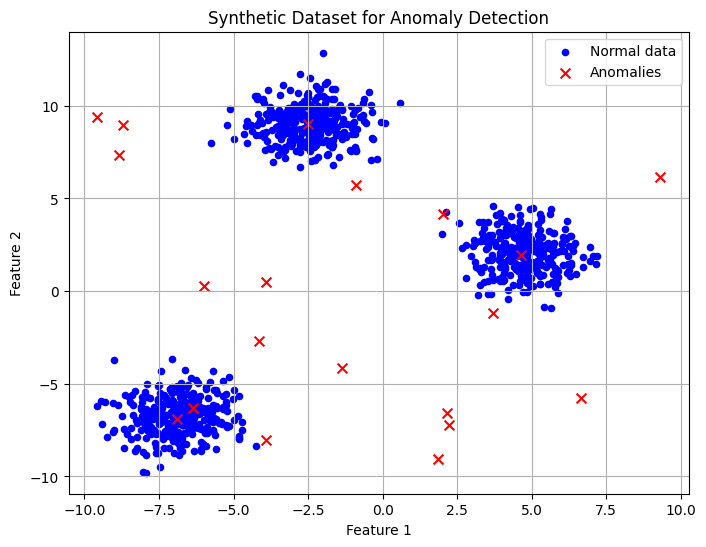

In [68]:
import numpy as np
from sklearn.datasets import make_blobs

# Generate a synthetic dataset with 2 features and 3 clusters
n_samples = 980
n_features = 2
n_centers = 3
random_state = 42

X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_centers, random_state=random_state)
y[:] = 1

# Introduce some anomalies (outliers)
n_outliers = 20
rng = np.random.RandomState(random_state)
outliers = rng.uniform(low=-10, high=10, size=(n_outliers, n_features))

# Combine the normal data with anomalies
X_combined = np.vstack([X, outliers])
y_combined = np.hstack([y, -np.ones(n_outliers)])

print(f"Original data shape: {X.shape}")
print(f"Outliers data shape: {outliers.shape}")
print(f"Combined dataset shape: {X_combined.shape}")

# You can visualize this data to see the anomalies
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='blue', s=20, label='Normal data')
plt.scatter(outliers[:, 0], outliers[:, 1], c='red', s=50, marker='x', label='Anomalies')
plt.title('Synthetic Dataset for Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


In [69]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# Criação e ajuste do modelo
model = IsolationForest()

model.fit(X_combined)

# Cálculo dos scores de anomalia
scores = model.decision_function(X_combined)
labels_default = model.predict(X_combined)  # -1 = anômalo, 1 = normal

              precision    recall  f1-score   support

        -1.0       0.06      0.80      0.11        20
         1.0       0.99      0.75      0.85       980

    accuracy                           0.75      1000
   macro avg       0.53      0.77      0.48      1000
weighted avg       0.98      0.75      0.84      1000



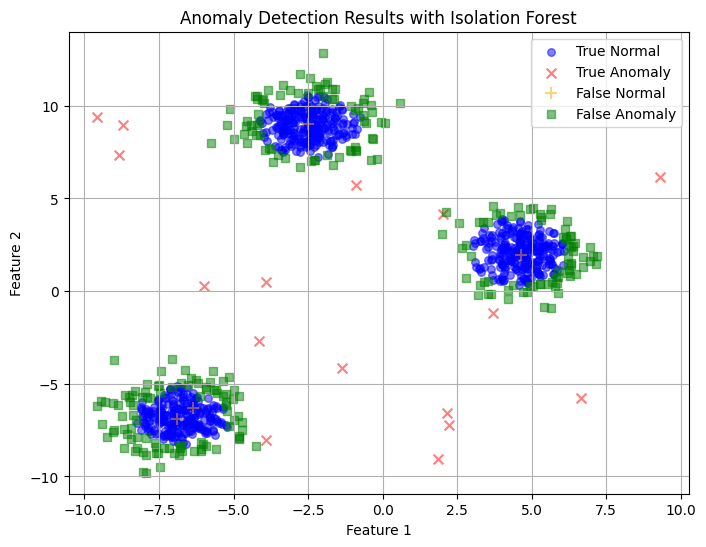

In [70]:
import matplotlib.pyplot as plt

def plot_results(X, y, labels):
    true_normal = X[np.logical_and((labels == 1), (y == 1))]
    true_anomaly = X[np.logical_and((labels == -1), (y == -1))]
    false_normal = X[np.logical_and((labels == 1), (y == -1))]
    false_anomaly = X[np.logical_and((labels == -1), (y == 1))]

    plt.figure(figsize=(8, 6))
    plt.scatter(true_normal[:, 0], true_normal[:, 1], c='blue', marker='o', s=30, label='True Normal', alpha=0.5)
    plt.scatter(true_anomaly[:, 0], true_anomaly[:, 1], c='red', marker='x', s=50, label='True Anomaly', alpha=0.5)
    plt.scatter(false_normal[:, 0], false_normal[:, 1], c='orange', marker='+', s=80, label='False Normal', alpha=0.5)
    plt.scatter(false_anomaly[:, 0], false_anomaly[:, 1], c='green', marker='s', s=30, label='False Anomaly', alpha=0.5)

    plt.title('Anomaly Detection Results with Isolation Forest')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)

print(classification_report(y_combined, labels_default))
plot_results(X_combined, y_combined, labels_default)
plt.show()

In [71]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score
import optuna


def objective(trial):
    # Suggest hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_samples = trial.suggest_float('max_samples', 0.1, 1.0)
    contamination = trial.suggest_float('contamination', 0.01, 0.1)
    max_features = trial.suggest_float('max_features', 0.5, 1.0)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])

    # Instantiate and train the Isolation Forest model
    model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        contamination=contamination,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=42 # Ensure reproducibility
    )
    model.fit(X_combined)

    # Predict labels
    labels = model.predict(X_combined)

    # Calculate F1-score for the anomalous class (-1)
    f1 = f1_score(y_combined, labels, pos_label=-1)

    return f1


# Create an Optuna study and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Print the best trial and its parameters
print("\nNumber of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2025-11-12 20:09:58,146] A new study created in memory with name: no-name-0d5d0b83-7071-4c3c-8cc0-504721012ca7
[I 2025-11-12 20:09:58,788] Trial 0 finished with value: 0.35294117647058826 and parameters: {'n_estimators': 430, 'max_samples': 0.42831877083678704, 'contamination': 0.030702508856035884, 'max_features': 0.6450346316248619, 'bootstrap': False}. Best is trial 0 with value: 0.35294117647058826.
[I 2025-11-12 20:09:59,080] Trial 1 finished with value: 0.2564102564102564 and parameters: {'n_estimators': 186, 'max_samples': 0.9604834147824305, 'contamination': 0.05804478604794481, 'max_features': 0.7463141084377736, 'bootstrap': True}. Best is trial 0 with value: 0.35294117647058826.
[I 2025-11-12 20:09:59,328] Trial 2 finished with value: 0.31746031746031744 and parameters: {'n_estimators': 168, 'max_samples': 0.16075554741792175, 'contamination': 0.04290952967687803, 'max_features': 0.5933475042988754, 'bootstrap': True}. Best is trial 0 with value: 0.35294117647058826.
[I 2


Number of finished trials:  50
Best trial:
  Value:  0.391304347826087
  Params: 
    n_estimators: 309
    max_samples: 0.6584435188531554
    contamination: 0.025087865678804097
    max_features: 0.6286663451152052
    bootstrap: False


Classification Report for Optimized Isolation Forest Model:
              precision    recall  f1-score   support

        -1.0       0.35      0.45      0.39        20
         1.0       0.99      0.98      0.99       980

    accuracy                           0.97      1000
   macro avg       0.67      0.72      0.69      1000
weighted avg       0.98      0.97      0.97      1000



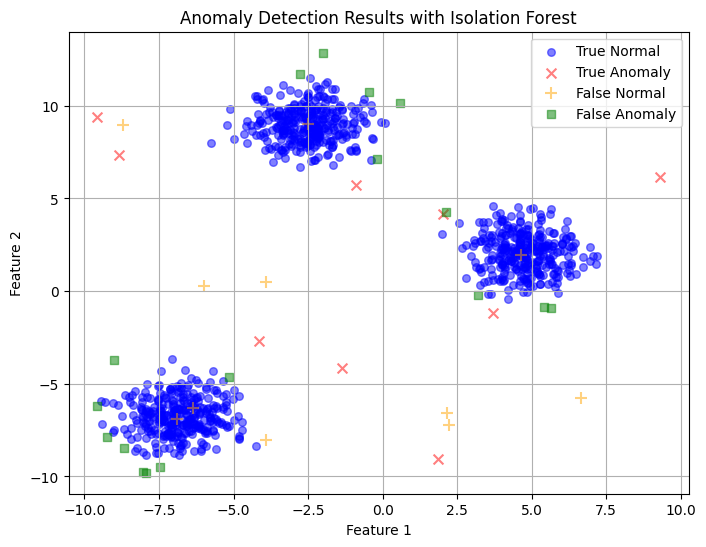

In [72]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

def evaluate_study_trial(trial):
    # Retrieve the best hyperparameters from the Optuna study
    best_params = trial.params

    # Instantiate the Isolation Forest model with the best hyperparameters
    optimized_model = IsolationForest(
        n_estimators=best_params['n_estimators'],
        max_samples=best_params['max_samples'],
        contamination=best_params['contamination'],
        max_features=best_params['max_features'],
        bootstrap=best_params['bootstrap'],
        random_state=42 # Ensure reproducibility
    )

    # Train the optimized model
    optimized_model.fit(X_combined)

    # Predict labels using the optimized model
    labels = optimized_model.predict(X_combined)

    # Evaluate the optimized model's performance
    print("Classification Report for Optimized Isolation Forest Model:")
    print(classification_report(y_combined, labels))
    plot_results(X_combined, y_combined, labels)
evaluate_study_trial(study.best_trial)
plt.show()

[I 2025-11-12 20:16:34,864] A new study created in memory with name: no-name-9f93c6b0-ad66-4a30-9bad-a60d83b3cbb8
[I 2025-11-12 20:16:35,143] Trial 0 finished with value: 0.42452830188679247 and parameters: {'n_estimators': 166, 'max_samples': 0.9093891732473325, 'contamination': 0.03134060624387545, 'max_features': 0.6640061337724172, 'bootstrap': False}. Best is trial 0 with value: 0.42452830188679247.
[I 2025-11-12 20:16:35,507] Trial 1 finished with value: 0.3465346534653465 and parameters: {'n_estimators': 220, 'max_samples': 0.7113859407708076, 'contamination': 0.02139197726202405, 'max_features': 0.698123917218711, 'bootstrap': False}. Best is trial 0 with value: 0.42452830188679247.
[I 2025-11-12 20:16:35,761] Trial 2 finished with value: 0.44280442804428044 and parameters: {'n_estimators': 169, 'max_samples': 0.42115583991804484, 'contamination': 0.09010411561299585, 'max_features': 0.958238123756101, 'bootstrap': False}. Best is trial 2 with value: 0.44280442804428044.
[I 202


Number of finished trials:  50
Best trial:
  Value:  0.45977011494252873
  Params: 
    n_estimators: 234
    max_samples: 0.4048958316678498
    contamination: 0.08056446743530037
    max_features: 0.894131199153506
    bootstrap: False
Classification Report for Optimized Isolation Forest Model:
              precision    recall  f1-score   support

        -1.0       0.15      0.60      0.24        20
         1.0       0.99      0.93      0.96       980

    accuracy                           0.92      1000
   macro avg       0.57      0.76      0.60      1000
weighted avg       0.97      0.92      0.95      1000



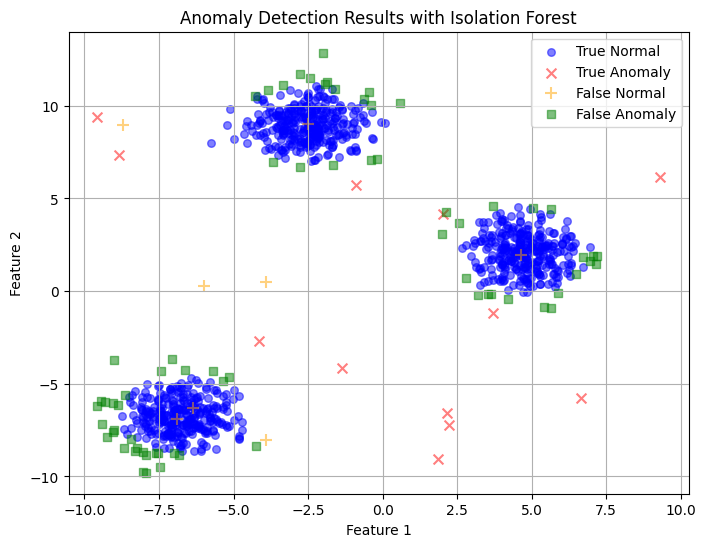

In [77]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import fbeta_score
import optuna


def objective(trial):
    # Suggest hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_samples = trial.suggest_float('max_samples', 0.1, 1.0)
    contamination = trial.suggest_float('contamination', 0.01, 0.1)
    max_features = trial.suggest_float('max_features', 0.5, 1.0)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])

    # Instantiate and train the Isolation Forest model
    model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        contamination=contamination,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=42 # Ensure reproducibility
    )
    model.fit(X_combined)

    # Predict labels
    labels = model.predict(X_combined)

    fbeta = fbeta_score(y_combined, labels, beta=3, pos_label=-1)

    return fbeta


# Create an Optuna study and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Print the best trial and its parameters
print("\nNumber of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

evaluate_study_trial(study.best_trial)
plt.show()